<a href="https://colab.research.google.com/github/MR-Goldenyt/Argus/blob/main/Argus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# IT7009 Artificial Intelligence - Selected Project Brief #2

## Intelligent Cyberattack Analysis System


## Phase 1: Data Cleaning and Preprocessing


### i. Imports and Data Loading


In [271]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Upload this file to the Colab session storage first
DATASET_PATH = "Dataset_Brief_2.csv"

# dirty data frame for future comparisons with clean data
ddf = pd.read_csv(DATASET_PATH, low_memory=False)

# cleaned dataset
df = ddf.copy()

# Display the raw dataset
print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (48826, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,4.835233,1713517.54,16.89,66.33,634.919224,634.919224,0.0,0.0,0.0,0.0,...,23.51914405190254,540.23,8.375931e+07,9.5,32.983477,31.837886,3663.34722,0.14,141.55,Mirai-udpplain
1,0.000000,54.0,6.0,64.00,2.671835,2.671835,0.0,0.0,1.0,0.0,...,0.0,54.0,8.297303e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DoS-SYN_Flood
2,0.000000,54.0,6.0,64.00,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,54.0,8.333120e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-PSHACK_Flood
3,0.000000,0.0,1.0,64.00,160.127665,160.127665,0.0,0.0,0.0,0.0,...,0.0,42.0,8.312889e+07,9.5,9.165151,0.000000,0.00000,0.0,141.55,DDoS-ICMP_Flood
4,0.000000,54.0,6.0,64.00,1.262448,1.262448,0.0,1.0,0.0,1.0,...,0.0,54.0,8.334516e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-RSTFINFlood


### ii. Overall Analysis of Raw Data


In [272]:
# Brief Information
print(df.info())

# Statistical Summary
df.describe(include="all").T.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   flow_duration    48815 non-null  float64
 1   Header_Length    48815 non-null  str    
 2   Protocol Type    48816 non-null  str    
 3   Duration         48816 non-null  float64
 4   Rate             48814 non-null  float64
 5   Srate            48816 non-null  float64
 6   Drate            48811 non-null  float64
 7   fin_flag_number  48814 non-null  float64
 8   syn_flag_number  48816 non-null  float64
 9   rst_flag_number  48815 non-null  float64
 10  psh_flag_number  48815 non-null  str    
 11  ack_flag_number  48814 non-null  float64
 12  ece_flag_number  48816 non-null  float64
 13  cwr_flag_number  48816 non-null  float64
 14  ack_count        48816 non-null  float64
 15  syn_count        48813 non-null  float64
 16  fin_count        48815 non-null  float64
 17  urg_count        48816 

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_duration,48815.0,NaN,NaN,NaN,14.495303,382.599894,-999.0,0.0,0.0,0.128624,47629.094561
Header_Length,48815,15623,54.0,14557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol Type,48816,915,6.0,22721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,48816.0,NaN,NaN,NaN,66.276401,12.9069,0.0,64.0,64.0,64.0,255.0
Rate,48814.0,NaN,NaN,NaN,8664.10689,89626.647942,-999.0,2.095422,15.69341,128.325003,3145728.0
Srate,48816.0,NaN,NaN,NaN,8663.824629,89624.823444,-999.0,2.095305,15.69341,128.351765,3145728.0
Drate,48811.0,NaN,NaN,NaN,0.000001,0.000089,0.0,0.0,0.0,0.0,0.014636
fin_flag_number,48814.0,NaN,NaN,NaN,0.083583,0.276764,0.0,0.0,0.0,0.0,1.0
syn_flag_number,48816.0,NaN,NaN,NaN,0.204359,0.403237,0.0,0.0,0.0,0.0,1.0
rst_flag_number,48815.0,NaN,NaN,NaN,0.088559,0.284109,0.0,0.0,0.0,0.0,1.0


### iii. Categorical, Temporal, and Identifier Audit


In [273]:
feature_cols = [c for c in df.columns if c != "label"]
print("Number of feature columns:", len(feature_cols))
print(f"\nColumn dtypes as read:\n{df.dtypes.value_counts()}")
print("\nAny column name suggesting an identifier/date field?")
suspect = [
    c
    for c in df.columns
    if any(k in c.lower() for k in ["id", "date", "time", "timestamp"])
    and c != "flow_duration"
]
print(
    suspect
    if suspect
    else "None found (besides the numeric duration/IAT features, which are not timestamps)."
)
print(
    "\nTarget classes:",
    df["label"].nunique(),
    "| Missing labels:",
    df["label"].isnull().sum(),
)

Number of feature columns: 46

Column dtypes as read:
float64    34
str        13
Name: count, dtype: int64

Any column name suggesting an identifier/date field?
None found (besides the numeric duration/IAT features, which are not timestamps).

Target classes: 33 | Missing labels: 0


### iv. Missing Values and Incorrect Data Types

`df.info()` above shows several columns that should be purely numeric (e.g. `Header_Length`,
`Protocol Type`, etc.) are instead read as `object` type. Inspecting the non-numeric
entries reveals the literal text tokens **`"invalid"`** and **`"unknown"`** planted inside otherwise
numeric cells not a genuine category.

**Proposed Solution:** replace these text tokens with `NaN`, then impute every feature column to numeric dtype.


======== Before ========
Total non-numeric values: 12
Total Missing values: 520
Identfied 2 non-numeric (text) values: ['unknown' 'invalid']
Feature columns with wrong (text) dtype:
01  Header_Length
02  Protocol Type
03  psh_flag_number
04  rst_count
05  HTTPS
06  ICMP
07  IPv
08  LLC
09  Min
10  Std
11  Tot size
12  Variance

======== After ========
Total non-numeric values: 0
Total Missing values: 532
Identfied 0 non-numeric (text) values: []
Feature columns with wrong (text) dtype: (should be empty):

All 46 feature columns are now numeric typed: True


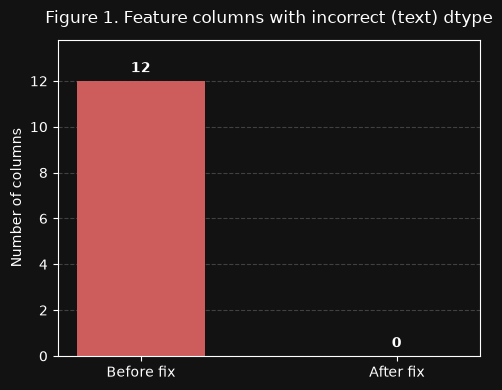

In [274]:
def get_non_numeric_values(data):
    """
    Identifies and returns all non-numeric (text/object) values from a DataFrame.
    Returns a Pandas Series of the raw values (including duplicates).
    """
    # 1. Create the boolean mask
    is_non_numeric = data.map(
        lambda x: pd.notna(x) and pd.isna(pd.to_numeric(x, errors="coerce"))
    )
    
    # 2. Filter and extract the values
    return data.stack()[is_non_numeric.stack()]

# Features only dataframe
features = df[feature_cols]

# Get both the non-numeric and unique non-numeric values
non_numbers = get_non_numeric_values(features)
unique_non_numbers = non_numbers.unique()

print("======== Before ========")
print("Total non-numeric values:", len(non_numbers))
# Print total missing and non-numeric values
print("Total Missing values:", df.isna().sum().sum())

# Print unique non-numeric values
print(f"Identfied {len(unique_non_numbers)} non-numeric (text) values: {unique_non_numbers}")

# Print feature cols that contain non-numeric values
object_cols_before = (
    df[feature_cols].select_dtypes(include=["str", "object"]).columns.to_list() # note: use "str" in include to avoid pandas warning
)
print("Feature columns with wrong (text) dtype:")
# Format print for readability
for idx, col in enumerate(object_cols_before, start=1):
    print(f"{idx:02d}  {col}")

# Clean inconsistent values by replacing and coercing as nan
df[feature_cols] = df[feature_cols].replace(unique_non_numbers, np.nan)
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Get both the non-numeric and unique non-numeric values
non_numbers = get_non_numeric_values(df[feature_cols])
unique_non_numbers = non_numbers.unique()

print("\n======== After ========")
print("Total non-numeric values:", len(non_numbers))
# Print total missing and non-numeric values
print("Total Missing values:", df.isna().sum().sum())

# Print unique non-numeric values
print(f"Identfied {len(unique_non_numbers)} non-numeric (text) values: {unique_non_numbers}")
# Print feature cols that still contain non-numeric values (should be empty)
object_cols_after = (
    df[feature_cols].select_dtypes(include=["str", "object"]).columns.to_list()
)
print("Feature columns with wrong (text) dtype: (should be empty):")
# Format print for readability
for idx, col in enumerate(object_cols_after, start=1):
    print(f"{idx:02d}  {col}")

print("\nAll 46 feature columns are now numeric typed:", len(object_cols_after) == 0)

# Store values for bar chart
values = [len(object_cols_before), len(object_cols_after)]
categories = ["Before fix", "After fix"]

# Initialize figure and axes
fig, ax = plt.subplots(figsize=(5, 4))

# Set bar chart attributes
ax.bar(
    categories,
    values,
    color=["indianred", "seagreen"], 
    width=0.5
)

# Set background colors (Grey style)
fig.patch.set_facecolor('#121212') 
ax.set_facecolor('#121212')

# Set titles and labels
ax.set_title("Figure 1. Feature columns with incorrect (text) dtype", pad=12)
ax.set_ylabel("Number of columns")

# Add headroom to Y-axis so text labels aren't clipped at the top
max_val = max(values) if values else 1
ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1)

# Add text labels above bars
for i, v in enumerate(values):
    ax.text(i, v + (max_val * 0.02), str(v), ha="center", va="bottom", fontweight="bold", color="white")

# Add subtle horizontal gridlines for readability
ax.grid(True, axis='y', linestyle='--', alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()

# Saving bar chart to file
# plt.savefig("fig1_dtype_fix.png", dpi=240)

### Detecting and Fixing Outliers using Interquartile Range (IQR)